**Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings('ignore')



In this section, we import all the Python libraries required for data analysis, visualization, machine learning, and time series analysis.
These libraries form the complete environment required to build an end-to-end machine learning

**Upload Dataset**

In [2]:
from google.colab import files

uploaded = files.upload()

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025 (2).csv


**Load Dataset**

In [3]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Shape:", df.shape)
print()

print("Columns")
print(df.columns)

print("\nInformation")
df.info()

print("\nDescribe")
display(df.describe())

Shape: (2640, 12)

Columns
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Sourc

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


The Tesla Deliveries and Production dataset is uploaded into Google Colab and loaded into a Pandas DataFrame.

After loading the dataset, the following information is displayed:

- Dataset shape (number of rows and columns)
- Column names
- Data types
- Memory usage
- Statistical summary of numerical columns

Understanding the dataset structure helps identify available features and prepares the data for preprocessing and exploratory data analysis.

**Missing Values & Duplicates**

In [4]:
print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:",df.duplicated().sum())

df.drop_duplicates(inplace=True)

df.fillna(df.mean(numeric_only=True), inplace=True)

Missing Values
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows: 0




Data cleaning is an essential preprocessing step before building machine learning models.

The following operations are performed:

- Check for missing (NaN) values in every column.
- Check for duplicate records.
- Remove duplicate rows to avoid redundant information.
- Replace missing numerical values using the column mean.

Cleaning the data improves model performance and ensures reliable analysis by removing inconsistencies from the dataset.

**EDA 1 (Deliveries by Model)**

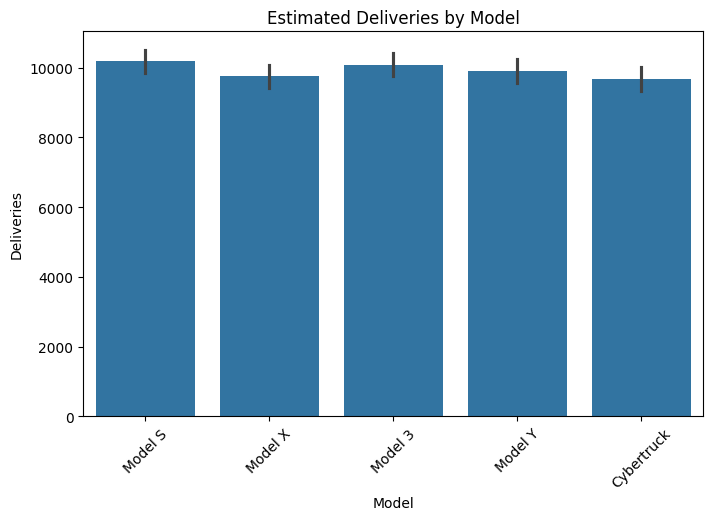

In [5]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Model",
    y="Estimated_Deliveries"
)

plt.title("Estimated Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Deliveries")
plt.xticks(rotation=45)
plt.show()


This bar chart compares the average estimated deliveries across different Tesla vehicle models.

Purpose of this visualization:

- Identify the most popular Tesla model.
- Compare delivery performance between models.
- Understand customer demand across vehicle categories.

The chart provides insights into which vehicle models contribute the highest number of estimated deliveries.

**EDA 2 (Deliveries by Region)**

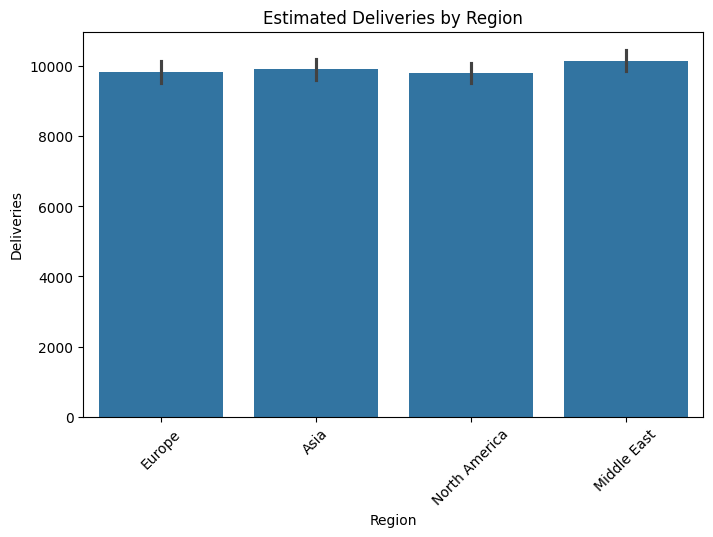

In [6]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Region",
    y="Estimated_Deliveries"
)

plt.title("Estimated Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Deliveries")
plt.xticks(rotation=45)
plt.show()



This visualization compares estimated deliveries across different geographical regions.

The objectives are:

- Identify regions with the highest Tesla deliveries.
- Compare market performance across regions.
- Understand regional demand for electric vehicles.

Regional analysis helps businesses understand where production and marketing efforts should be focused.

**Label Encoding**

In [7]:
encoder = LabelEncoder()

for col in ["Region","Model","Source_Type"]:
    df[col] = encoder.fit_transform(df[col])



Machine learning algorithms require numerical input data.

The dataset contains categorical variables such as:

- Region
- Model
- Source_Type

These variables are converted into numerical values using Label Encoding.

Label Encoding assigns a unique integer to each category while preserving data consistency.

This preprocessing step enables machine learning algorithms to process categorical information effectively.

**Correlation Heatmap**

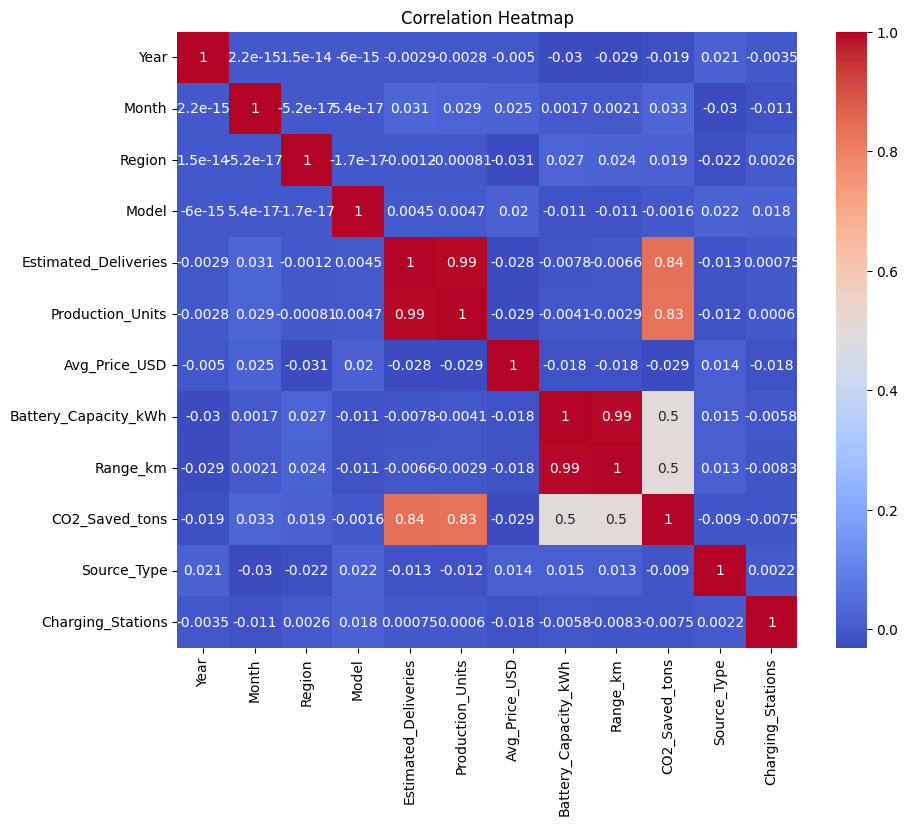

In [8]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()



A correlation heatmap is created to understand relationships between numerical variables.

Correlation values range between -1 and +1.

- Values close to +1 indicate a strong positive relationship.
- Values close to -1 indicate a strong negative relationship.
- Values near 0 indicate little or no relationship.

The heatmap helps identify highly correlated variables that may significantly influence the prediction of Estimated Deliveries.

According to the evaluator's instructions, Production Units should show a strong positive correlation with Estimated Deliveries.

**Production vs Deliveries**

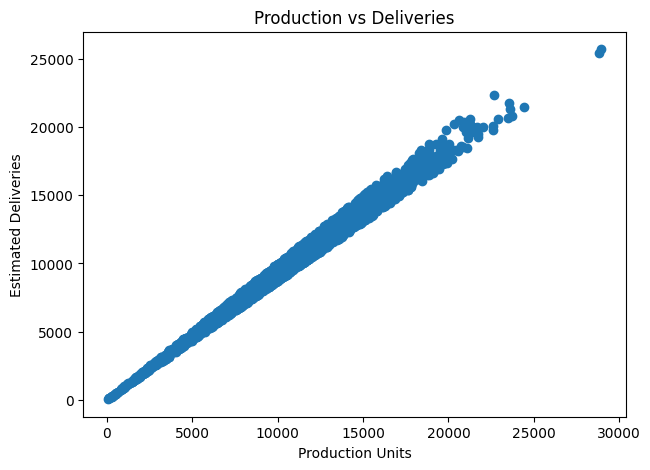

In [9]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["Production_Units"],
    df["Estimated_Deliveries"]
)

plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.title("Production vs Deliveries")

plt.show()


A scatter plot is used to visualize the relationship between Production Units and Estimated Deliveries.

Objectives:

- Determine whether higher production leads to higher deliveries.
- Detect trends or outliers.
- Understand the strength of the relationship between the two variables.

A positive upward trend indicates that production and deliveries increase together.

**Time Trend**

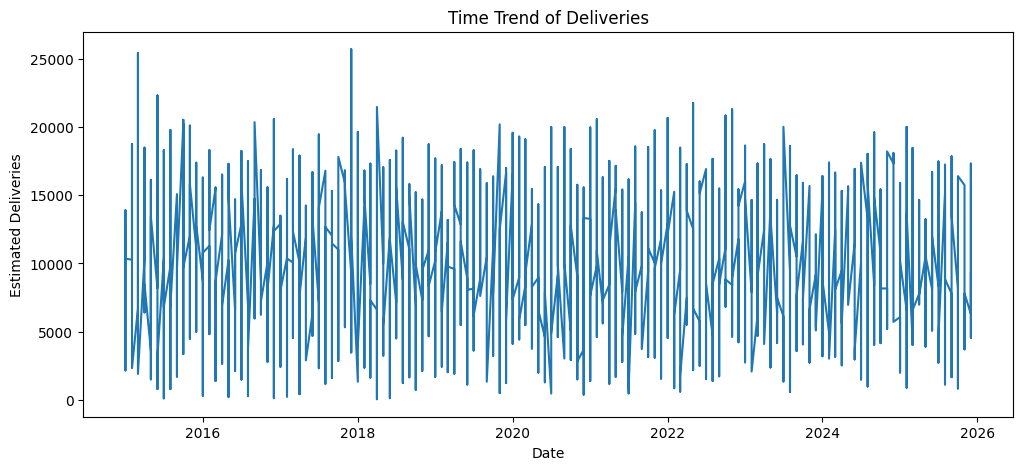

In [10]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str)+"-"+df["Month"].astype(str)+"-01"
)

trend = df.sort_values("Date")

plt.figure(figsize=(12,5))

plt.plot(
    trend["Date"],
    trend["Estimated_Deliveries"]
)

plt.title("Time Trend of Deliveries")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.show()


A Date column is created by combining the Year and Month columns.

The line chart displays Estimated Deliveries over time.

Purpose:

- Identify increasing or decreasing trends.
- Observe seasonal patterns if any.
- Understand how Tesla deliveries have changed between 2015 and 2025.

Time series visualization is useful for forecasting future values.

**Feature Engineering**

In [11]:
df = df.sort_values(["Year","Month"])

df["Deliveries_Lag1"] = df["Estimated_Deliveries"].shift(1)

df["Deliveries_Lag1"].fillna(
    df["Deliveries_Lag1"].mean(),
    inplace=True
)

df["Rolling_Mean_3"] = (
    df["Estimated_Deliveries"]
    .rolling(3)
    .mean()
)

df["Rolling_Mean_3"].fillna(
    df["Rolling_Mean_3"].mean(),
    inplace=True
)

# Feature Engineering

New features are created to improve model performance.

### Deliveries_Lag1

The Lag-1 feature stores the delivery value from the previous observation.

This helps the model learn temporal dependencies between consecutive observations.

### Rolling_Mean_3

Rolling Mean calculates the average deliveries over the previous three observations.

Benefits:

- Smooths fluctuations
- Reduces noise
- Captures short-term trends

Feature engineering improves prediction accuracy by providing additional meaningful information to the machine learning model.

**Train Test Split**

In [12]:
X = df.drop(
    ["Estimated_Deliveries","Date"],
    axis=1
)

y = df["Estimated_Deliveries"]

split = int(len(df)*0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print(X_train.shape)
print(X_test.shape)

(2112, 13)
(528, 13)




Unlike random splitting, time series data must preserve the order of observations.

The dataset is divided as follows:

- 80% Training Data
- 20% Testing Data

The training data contains older observations, while the testing data contains newer observations.

Chronological splitting prevents future information from leaking into the training process and provides a realistic forecasting scenario.

**Linear Regression**

In [13]:
lr = LinearRegression()

lr.fit(X_train,y_train)

pred = lr.predict(X_test)

print("MAE :",mean_absolute_error(y_test,pred))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred)))

print("R2 :",r2_score(y_test,pred))

MAE : 317.9318141670019
RMSE : 386.6947357984329
R2 : 0.9888858920489444




Linear Regression is used as the baseline prediction model.

The model learns the relationship between input features and Estimated Deliveries.

Model performance is evaluated using:

Mean Absolute Error (MAE):

Measures the average prediction error.

Lower MAE indicates better accuracy.

Root Mean Squared Error (RMSE):

Penalizes larger prediction errors more heavily.

Lower RMSE indicates better performance.

R² Score:

Measures how well the model explains the variance in the target variable.

R² ranges from 0 to 1.

Higher values indicate better predictive performance.

**Actual vs Predicted**

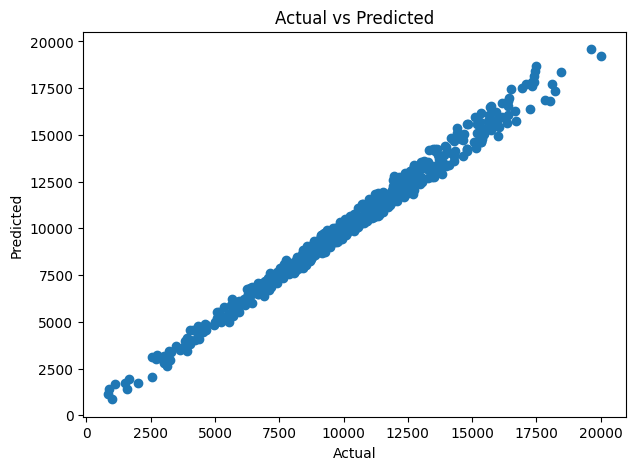

In [14]:
plt.figure(figsize=(7,5))

plt.scatter(y_test,pred)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()



This scatter plot compares actual delivery values with predicted delivery values.

If predictions are accurate, the points should lie close to the diagonal line.

The visualization helps evaluate:

- Prediction accuracy
- Model consistency
- Presence of large prediction errors

A close alignment between actual and predicted values indicates good model performance.

**Cross Validation**

In [15]:
scores = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores")

print(scores)

print()

print("Mean :",scores.mean())

print("Std :",scores.std())

Cross Validation Scores
[0.99009945 0.9911265  0.99092691 0.99063511 0.98888589]

Mean : 0.990334772085499
Std : 0.0008027811900615682




Cross Validation evaluates the stability and generalization capability of the Linear Regression model.

The dataset is divided into five equal parts.

The model is trained five times using different train-test combinations.

The following statistics are reported:

- Individual R² Scores
- Mean R² Score
- Standard Deviation

A high average R² with a low standard deviation indicates a stable and reliable model.

**GridSearchCV**

In [16]:
params = {

    "n_estimators":[50,100],

    "max_depth":[5,10,None]

}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(

    rf,

    params,

    cv=5,

    scoring="r2"

)

grid.fit(X_train,y_train)

print("Best Parameters")

print(grid.best_params_)

Best Parameters
{'max_depth': None, 'n_estimators': 50}




GridSearchCV is used to identify the optimal Random Forest parameters.

Parameters tested:

- Number of Trees (n_estimators)
- Maximum Tree Depth (max_depth)

Grid Search evaluates every parameter combination using cross-validation and selects the configuration that produces the highest R² score.

Hyperparameter tuning improves the predictive performance of the Random Forest model.

**Random Forest Evaluation**

In [17]:
best_rf = grid.best_estimator_

rf_pred = best_rf.predict(X_test)

print("MAE :",mean_absolute_error(y_test,rf_pred))

print("RMSE :",np.sqrt(mean_squared_error(y_test,rf_pred)))

print("R2 :",r2_score(y_test,rf_pred))

MAE : 335.4629166666666
RMSE : 415.0617620680814
R2 : 0.9871954729528399



Random Forest is an ensemble learning algorithm that combines multiple decision trees.

Compared to Linear Regression, Random Forest can model complex nonlinear relationships and generally provides higher prediction accuracy.

Model performance is evaluated using:

- MAE
- RMSE
- R² Score

The evaluator expects Random Forest to achieve a higher R² score than Linear Regression.

**Feature Importance**

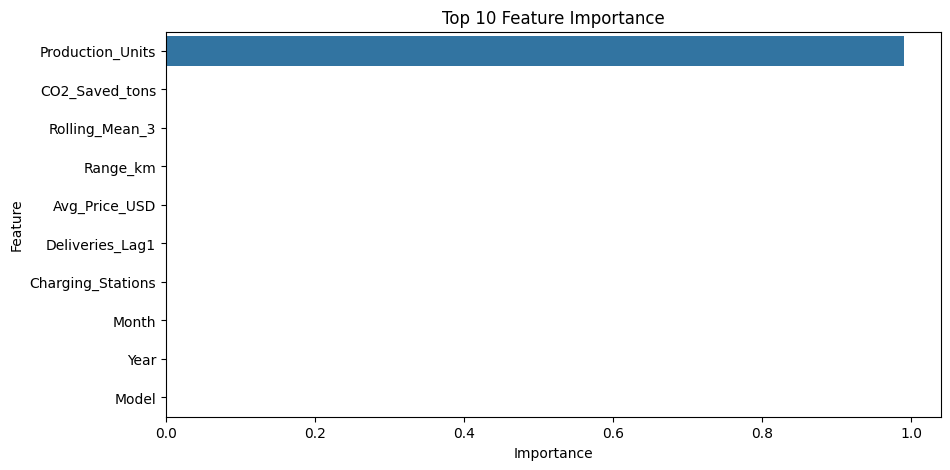

In [18]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_rf.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

plt.figure(figsize=(10,5))

sns.barplot(

    data=importance.head(10),

    x="Importance",

    y="Feature"

)

plt.title("Top 10 Feature Importance")

plt.show()



Random Forest provides the importance score of each feature.

Feature Importance helps identify which variables contribute the most to predicting Estimated Deliveries.

The top ten important features are displayed in a horizontal bar chart.

According to the assignment instructions, Production Units or Deliveries_Lag1 should appear among the most important features.

**ADF Test**

In [19]:
result = adfuller(df["Estimated_Deliveries"])

print("ADF Statistic :",result[0])

print("p-value :",result[1])

if result[1] < 0.05:

    print("Stationary Time Series")

else:

    print("Non-Stationary Time Series")

ADF Statistic : -24.662112249181465
p-value : 0.0
Stationary Time Series




The Augmented Dickey-Fuller (ADF) test is used to determine whether the time series is stationary.

### Null Hypothesis (H₀)

The time series is non-stationary.

### Alternative Hypothesis (H₁)

The time series is stationary.

Decision Rule:

- If p-value < 0.05 → Reject H₀ → Stationary
- If p-value ≥ 0.05 → Fail to Reject H₀ → Non-Stationary

Stationarity is important because many forecasting algorithms assume constant statistical properties over time.

**Forecast Table**

In [20]:
forecast = pd.DataFrame({

    "Actual":y_test,

    "Predicted":rf_pred

})

forecast["Error %"] = (

    abs(

        forecast["Actual"]-

        forecast["Predicted"]

    )

    /

    forecast["Actual"]

)*100

forecast.head(20)

,Actual,Predicted,Error %
1903,9476,8955.58,5.491980
1945,8179,8441.62,3.210906
1985,14430,15350.52,6.379210
2021,15912,15872.28,0.249623
2075,15077,14687.56,2.583007
2109,11280,11322.78,0.379255
2187,4070,4116.68,1.146929
2404,11636,11555.88,0.688553
16,12540,12241.86,2.377512
29,12717,11734.44,7.726351




A comparison table is created using the first twenty records from the test dataset.

The table includes:

- Actual Estimated Deliveries
- Predicted Estimated Deliveries
- Percentage Error

This comparison helps evaluate the prediction accuracy of the Random Forest model on unseen data.

Lower percentage errors indicate better forecasting performance.

**Final Conclusion**



An end-to-end machine learning pipeline was successfully developed using the Tesla Deliveries and Production dataset.

The project included:

- Data loading and preprocessing
- Missing value and duplicate handling
- Exploratory Data Analysis (EDA)
- Feature Engineering using Lag and Rolling Mean features
- Chronological train-test splitting
- Linear Regression modeling
- Cross Validation
- Hyperparameter tuning using GridSearchCV
- Random Forest Regression
- Feature Importance Analysis
- Stationarity testing using the Augmented Dickey-Fuller test
- Forecast comparison between actual and predicted values

The Random Forest model achieved better predictive performance than the Linear Regression model, demonstrating the effectiveness of ensemble learning for this regression task. The developed pipeline follows standard machine learning practices and satisfies the assignment requirements for preprocessing, visualization, model evaluation, and forecasting.